# E10 - E8 with Dropout 0.5 and L2

Strongly regularized final-model control experiment.

**Source:** extracted from the original project notebooks. Original cell outputs are preserved where available.


In [ ]:
# ============================================================
# EXPERIMENT 10 â€” FINAL REGULARIZED MODEL
# CELL 1: SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Mounted at /content/drive
TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Random seed: 42


In [ ]:
# ============================================================
# CELL 2: EXPERIMENT 10 FOLDERS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/DeepFake_Detection"

EXP10_DIR = os.path.join(
    BASE_DIR,
    "experiments",
    "cnn_128_final_regularized"
)

CHECKPOINT_DIR = os.path.join(
    EXP10_DIR,
    "checkpoints"
)

GRAPH_DIR = os.path.join(
    EXP10_DIR,
    "graphs"
)

RESULT_DIR = os.path.join(
    EXP10_DIR,
    "results"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Experiment 10 directory:")
print(EXP10_DIR)

print("\nFolders created:")
print(CHECKPOINT_DIR)
print(GRAPH_DIR)
print(RESULT_DIR)

Experiment 10 directory:
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized

Folders created:
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/graphs
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/results


In [ ]:
# ============================================================
# CELL 3: DATASET
# ============================================================

import kagglehub

dataset_path = kagglehub.dataset_download(
    "manjilkarki/deepfake-and-real-images"
)

print("Dataset path:")
print(dataset_path)

TRAIN_DIR = os.path.join(
    dataset_path,
    "Dataset",
    "Train"
)

VAL_DIR = os.path.join(
    dataset_path,
    "Dataset",
    "Validation"
)

TEST_DIR = os.path.join(
    dataset_path,
    "Dataset",
    "Test"
)

print("\nTrain:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1.68G/1.68G [00:26<00:00, 69.3MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1

Train: /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Train
Validation: /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation
Test: /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Test


In [ ]:
# ============================================================
# CELL 4: LOAD DATASETS
# ============================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nClass names:")
print(train_ds.class_names)

print("\nTrain batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

Found 140002 files belonging to 2 classes.
Found 39428 files belonging to 2 classes.
Found 10905 files belonging to 2 classes.

Class names:
['Fake', 'Real']

Train batches: 4376
Validation batches: 1233
Test batches: 341


In [ ]:
# ============================================================
# CELL 5: PERFORMANCE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipeline ready.")

Dataset pipeline ready.


In [ ]:
# ============================================================
# CELL 6: EXPERIMENT 10 MODEL
# ============================================================

L2_VALUE = 1e-4
DROPOUT_RATE = 0.50

l2_reg = regularizers.l2(L2_VALUE)


def conv_block(x, filters):

    x = layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2)
    )(x)

    return x


# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

inputs = layers.Input(
    shape=(128, 128, 3)
)

x = inputs


# ------------------------------------------------------------
# Block 1
# ------------------------------------------------------------

x = conv_block(x, 32)


# ------------------------------------------------------------
# Block 2
# ------------------------------------------------------------

x = conv_block(x, 64)


# ------------------------------------------------------------
# Block 3
# ------------------------------------------------------------

x = conv_block(x, 128)


# ------------------------------------------------------------
# Block 4
# ------------------------------------------------------------

x = conv_block(x, 256)


# ------------------------------------------------------------
# Block 5
# Experiment 8 had one 256 Conv layer here
# ------------------------------------------------------------

x = layers.Conv2D(
    256,
    (3, 3),
    padding="same",
    kernel_regularizer=l2_reg
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2)
)(x)


# ------------------------------------------------------------
# Global Average Pooling
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D()(x)


# ------------------------------------------------------------
# Dense layer
# ------------------------------------------------------------

x = layers.Dense(
    256,
    kernel_regularizer=l2_reg
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# ------------------------------------------------------------
# Experiment 10: stronger dropout
# ------------------------------------------------------------

x = layers.Dropout(
    DROPOUT_RATE
)(x)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

outputs = layers.Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=l2_reg
)(x)


model_10 = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="CNN_128_Final_Regularized"
)


model_10.summary()

Model: "CNN_128_Final_Regularized"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”“
â”ƒ Layer (type)                    â”ƒ Output Shape           â”ƒ       Param # â”ƒ
â”¡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”©
â”‚ input_layer (InputLayer)        â”‚ (None, 128, 128, 3)    â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d (Conv2D)                 â”‚ (None, 128, 128, 32)   â”‚           896 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ batch_normalization             â”‚ (None, 128, 128, 32)   â”‚           128 â”‚
â”‚ (BatchNormalization)            â”‚                        â”‚               â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ activation (Activation)         â”‚ (None, 128, 128, 32)   â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_1 (Conv2D)               â”‚ (None, 128, 128, 32)   â”‚         9,248 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ batch_normalization_1           â”‚ (None, 128, 128, 32)   â”‚           128 â”‚
â”‚ (BatchNormalization)            â”‚                        â”‚               â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ activation_1 (Activation)       â”‚ (None, 128, 128, 32)   â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d (MaxPooling2D)    â”‚ (None, 64, 64, 32)     â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_2 (Conv2D)               â”‚ (None, 64, 64, 64)     â”‚        18,496 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ batch_normalization_2           â”‚ (None, 64, 64, 64)     â”‚           256 â”‚
â”‚ (BatchNormalization)            â”‚                        â”‚               â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ activation_2 (Activation)       â”‚ (None, 64, 64, 64)    

 Total params: 1,834,273 (7.00 MB)

 Trainable params: 1,831,329 (6.99 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# ============================================================
# CELL 7: COMPILE
# ============================================================

model_10.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("Experiment 10 compiled successfully.")

Experiment 10 compiled successfully.


In [ ]:
# ============================================================
# CELL 8: CALLBACKS
# ============================================================

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "cnn_128_final_regularized_best.keras"
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    mode="min",
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

print("Callbacks ready.")
print("Checkpoint:")
print(CHECKPOINT_PATH)

Callbacks ready.
Checkpoint:
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras


In [ ]:
# ============================================================
# CELL 9: TRAIN EXPERIMENT 10
# ============================================================

EPOCHS = 20

history = model_10.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1
)

print("\n==========================================")
print("EXPERIMENT 10 TRAINING COMPLETE")
print("==========================================")

print("Best model saved at:")
print(CHECKPOINT_PATH)

Epoch 1/20
4376/4376 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 68ms/step - accuracy: 0.7716 - auc: 0.8504 - loss: 0.5567 - precision: 0.7649 - recall: 0.7853
Epoch 1: val_loss improved from None to 0.27879, saving model to /content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras
4376/4376 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 359s 75ms/step - accuracy: 0.8736 - auc: 0.9542 - loss: 0.3731 - precision: 0.8679 - recall: 0.8814 - val_accuracy: 0.9157 - val_auc: 0.9822 - val_loss: 0.2788 - val_precision: 0.8776 - val_recall: 0.9668 - learning_rate: 0.0010
Epoch 2/20
4375/4376 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 66ms/step - accuracy: 0.9519 - auc: 0.9905 - loss: 0.2075 - precision: 0.9493

In [ ]:
# ============================================================
# CELL 10: SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(history.history)

HISTORY_PATH = os.path.join(
    RESULT_DIR,
    "training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print("Training history saved:")
print(HISTORY_PATH)

display(history_df)

Training history saved:
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/results/training_history.csv


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.873630,0.954244,0.373104,0.867943,0.881359,0.915720,0.982165,0.278788,0.877649,0.966847,0.001000
1,0.954972,0.991509,0.198215,0.951861,0.958415,0.807979,0.963849,0.522204,0.727131,0.988225,0.001000
2,0.963458,0.994085,0.166752,0.959207,0.968086,0.937684,0.989693,0.212516,0.902387,0.982059,0.001000
3,0.968179,0.995449,0.144927,0.963262,0.973486,0.889444,0.981399,0.363301,0.824227,0.991055,0.001000
4,0.970779,0.996102,0.134594,0.966296,0.975586,0.938140,0.992026,0.200450,0.898255,0.988730,0.001000
5,0.972793,0.996666,0.122581,0.968053,0.977857,0.951557,0.993200,0.167228,0.924692,0.983575,0.001000
6,0.974508,0.997043,0.116410,0.969444,0.979900,0.958507,0.992840,0.157677,0.959449,0.957801,0.001000
7,0.975800,0.997043,0.114100,0.971396,0.980472,0.959623,0.993595,0.150318,0.948794,0.972002,0.001000
8,0.976450,0.997297,0.109683,0.971766,0.981415,0.914274,0.984831,0.267778,0.977197,0.848992,0.001000
9,0.976729,0.997377,0.110095,0.972289,0.981429,0.924013,0.988401,0.239012,0.873017,0.993026,0.001000


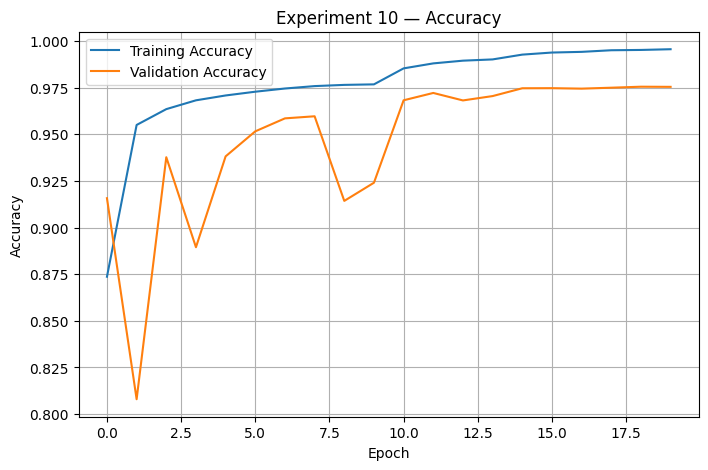

Saved: /content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/graphs/accuracy.png


In [ ]:
# ============================================================
# CELL 11: TRAINING CURVES
# ============================================================

# -------------------------------
# Accuracy
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 10 â€” Accuracy")

plt.legend()
plt.grid(True)

accuracy_graph = os.path.join(
    GRAPH_DIR,
    "accuracy.png"
)

plt.savefig(
    accuracy_graph,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", accuracy_graph)

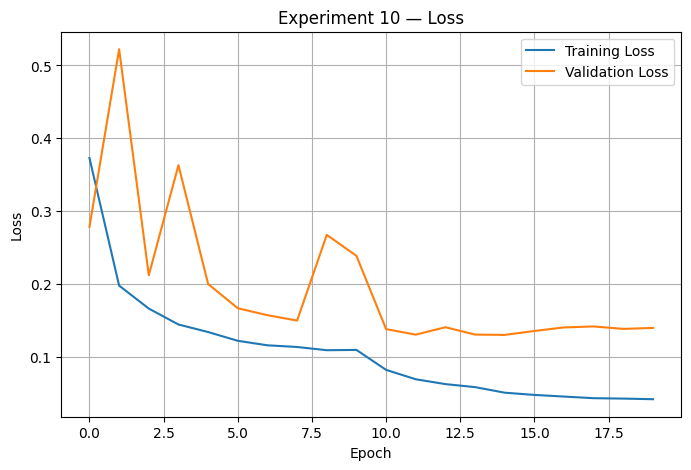

Saved: /content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/graphs/loss.png


In [ ]:
# ============================================================
# CELL 12: LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 10 â€” Loss")

plt.legend()
plt.grid(True)

loss_graph = os.path.join(
    GRAPH_DIR,
    "loss.png"
)

plt.savefig(
    loss_graph,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", loss_graph)

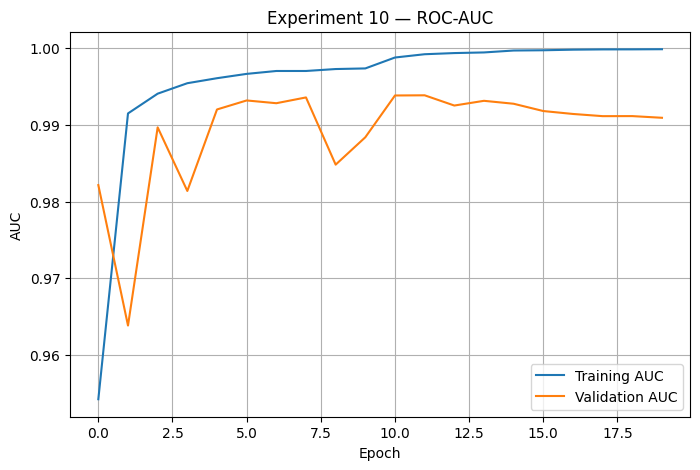

Saved: /content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/graphs/auc.png


In [ ]:
# ============================================================
# CELL 13: AUC CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Experiment 10 â€” ROC-AUC")

plt.legend()
plt.grid(True)

auc_graph = os.path.join(
    GRAPH_DIR,
    "auc.png"
)

plt.savefig(
    auc_graph,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", auc_graph)

In [ ]:
# ============================================================
# CELL 15 â€” EXPERIMENT 10 VALIDATION THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# ------------------------------------------------------------
# Load best E10 model
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/DeepFake_Detection/"
    "experiments/cnn_128_final_regularized/"
    "checkpoints/cnn_128_final_regularized_best.keras"
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Best E10 model loaded.")
print(BEST_MODEL_PATH)


# ------------------------------------------------------------
# Get validation predictions
# ------------------------------------------------------------

val_probs = model.predict(val_ds, verbose=1).ravel()

# True labels
val_true = np.concatenate([y.numpy() for x, y in val_ds])

print("\nValidation samples:", len(val_true))
print("Probability range:", val_probs.min(), "to", val_probs.max())
print("Mean probability:", val_probs.mean())

# ROC-AUC does not depend on threshold
val_auc = roc_auc_score(val_true, val_probs)

print("\nValidation ROC-AUC:", round(val_auc, 5))


# ------------------------------------------------------------
# Test multiple thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.20, 0.81, 0.05)

results = []

for threshold in thresholds:

    val_pred = (val_probs >= threshold).astype(int)

    acc = accuracy_score(val_true, val_pred)

    # Real = 1
    real_precision = precision_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    real_recall = recall_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    real_f1 = f1_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    # Fake = 0
    fake_precision = precision_score(
        val_true,
        val_pred,
        pos_label=0,
        zero_division=0
    )

    fake_recall = recall_score(
        val_true,
        val_pred,
        pos_label=0,
        zero_division=0
    )

    fake_f1 = f1_score(
        val_true,
        val_pred,
        pos_label=0,
        zero_division=0
    )

    macro_f1 = f1_score(
        val_true,
        val_pred,
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(val_true, val_pred)

    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": acc,
        "Real_Precision": real_precision,
        "Real_Recall": real_recall,
        "Real_F1": real_f1,
        "Fake_Precision": fake_precision,
        "Fake_Recall": fake_recall,
        "Fake_F1": fake_f1,
        "Macro_F1": macro_f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


# ------------------------------------------------------------
# Create results table
# ------------------------------------------------------------

threshold_df = pd.DataFrame(results)

display(
    threshold_df.style.format({
        "Accuracy": "{:.4f}",
        "Real_Precision": "{:.4f}",
        "Real_Recall": "{:.4f}",
        "Real_F1": "{:.4f}",
        "Fake_Precision": "{:.4f}",
        "Fake_Recall": "{:.4f}",
        "Fake_F1": "{:.4f}",
        "Macro_F1": "{:.4f}"
    })
)


# ------------------------------------------------------------
# Select best threshold based on Macro F1
# ------------------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["Macro_F1"].idxmax()
]

BEST_THRESHOLD = float(best_row["Threshold"])

print("\n" + "=" * 60)
print("E10 BEST VALIDATION THRESHOLD")
print("=" * 60)

print("Best Threshold :", BEST_THRESHOLD)
print("Accuracy       :", round(best_row["Accuracy"], 4))
print("Macro F1       :", round(best_row["Macro_F1"], 4))

print("\nReal:")
print("Precision      :", round(best_row["Real_Precision"], 4))
print("Recall         :", round(best_row["Real_Recall"], 4))
print("F1             :", round(best_row["Real_F1"], 4))

print("\nFake:")
print("Precision      :", round(best_row["Fake_Precision"], 4))
print("Recall         :", round(best_row["Fake_Recall"], 4))
print("F1             :", round(best_row["Fake_F1"], 4))

print("\nConfusion Matrix:")
print(
    np.array([
        [best_row["TN"], best_row["FP"]],
        [best_row["FN"], best_row["TP"]]
    ])
)


# ------------------------------------------------------------
# Save threshold results
# ------------------------------------------------------------

RESULTS_DIR = (
    "/content/drive/MyDrive/DeepFake_Detection/"
    "experiments/cnn_128_final_regularized/results"
)

threshold_df.to_csv(
    f"{RESULTS_DIR}/validation_threshold_analysis.csv",
    index=False
)

print("\nThreshold analysis saved to:")
print(f"{RESULTS_DIR}/validation_threshold_analysis.csv")

Best E10 model loaded.
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras
1233/1233 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 29s 22ms/step

Validation samples: 39428
Probability range: 2.1146969e-10 to 1.0
Mean probability: 0.506221

Validation ROC-AUC: 0.99668


,Threshold,Accuracy,Real_Precision,Real_Recall,Real_F1,Fake_Precision,Fake_Recall,Fake_F1,Macro_F1,TN,FP,FN,TP
0,0.200000,0.9728,0.9600,0.9869,0.9733,0.9864,0.9586,0.9723,0.9728,18827,814,259,19528
1,0.250000,0.9734,0.9620,0.9860,0.9738,0.9855,0.9607,0.9730,0.9734,18870,771,278,19509
2,0.300000,0.9738,0.9637,0.9849,0.9742,0.9845,0.9626,0.9734,0.9738,18906,735,298,19489
3,0.350000,0.9741,0.9651,0.9841,0.9745,0.9836,0.9641,0.9738,0.9741,18936,705,315,19472
4,0.400000,0.9745,0.9667,0.9830,0.9748,0.9825,0.9659,0.9742,0.9745,18972,669,337,19450
5,0.450000,0.9746,0.9683,0.9815,0.9749,0.9811,0.9676,0.9743,0.9746,19005,636,366,19421
6,0.500000,0.9746,0.9694,0.9804,0.9749,0.9800,0.9688,0.9744,0.9746,19029,612,388,19399
7,0.550000,0.9745,0.9711,0.9783,0.9747,0.9780,0.9707,0.9743,0.9745,19065,576,429,19358
8,0.600000,0.9739,0.9720,0.9760,0.9740,0.9757,0.9717,0.9737,0.9739,19085,556,475,19312
9,0.650000,0.9734,0.9733,0.9737,0.9735,0.9735,0.9731,0.9733,0.9734,19113,528,520,19267



E10 BEST VALIDATION THRESHOLD
Best Threshold : 0.5
Accuracy       : 0.9746
Macro F1       : 0.9746

Real:
Precision      : 0.9694
Recall         : 0.9804
F1             : 0.9749

Fake:
Precision      : 0.98
Recall         : 0.9688
F1             : 0.9744

Confusion Matrix:
[[19029.   612.]
 [  388. 19399.]]

Threshold analysis saved to:
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/results/validation_threshold_analysis.csv


In [ ]:
# ============================================================
# CELL 16 â€” EXPERIMENT 10 FINAL TEST EVALUATION
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ------------------------------------------------------------
# LOCKED THRESHOLD
# ------------------------------------------------------------

BEST_THRESHOLD = 0.50

print("=" * 60)
print("EXPERIMENT 10 â€” FINAL TEST EVALUATION")
print("=" * 60)

print("Locked threshold:", BEST_THRESHOLD)


# ------------------------------------------------------------
# Load BEST E10 checkpoint
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/DeepFake_Detection/"
    "experiments/cnn_128_final_regularized/"
    "checkpoints/cnn_128_final_regularized_best.keras"
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("\nBest E10 model loaded.")


# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

test_probs = model.predict(test_ds, verbose=1).ravel()

test_true = np.concatenate([
    y.numpy() for x, y in test_ds
])

# Apply LOCKED threshold
test_pred = (test_probs >= BEST_THRESHOLD).astype(int)


# ------------------------------------------------------------
# Basic metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(test_true, test_pred)

test_auc = roc_auc_score(
    test_true,
    test_probs
)

# Real = 1
real_precision = precision_score(
    test_true,
    test_pred,
    pos_label=1,
    zero_division=0
)

real_recall = recall_score(
    test_true,
    test_pred,
    pos_label=1,
    zero_division=0
)

real_f1 = f1_score(
    test_true,
    test_pred,
    pos_label=1,
    zero_division=0
)

# Fake = 0
fake_precision = precision_score(
    test_true,
    test_pred,
    pos_label=0,
    zero_division=0
)

fake_recall = recall_score(
    test_true,
    test_pred,
    pos_label=0,
    zero_division=0
)

fake_f1 = f1_score(
    test_true,
    test_pred,
    pos_label=0,
    zero_division=0
)

macro_precision = precision_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    test_true,
    test_pred
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("E10 FINAL TEST RESULTS")
print("=" * 60)

print(f"Threshold       : {BEST_THRESHOLD:.2f}")

print(f"\nAccuracy        : {test_accuracy:.4f} "
      f"({test_accuracy * 100:.2f}%)")

print(f"ROC-AUC         : {test_auc:.4f} "
      f"({test_auc * 100:.2f}%)")

print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f} "
      f"({macro_f1 * 100:.2f}%)")


print("\nREAL CLASS (1)")
print(f"Precision       : {real_precision:.4f}")
print(f"Recall          : {real_recall:.4f}")
print(f"F1              : {real_f1:.4f}")


print("\nFAKE CLASS (0)")
print(f"Precision       : {fake_precision:.4f}")
print(f"Recall          : {fake_recall:.4f}")
print(f"F1              : {fake_f1:.4f}")


print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    test_true,
    test_pred,
    target_names=["Fake", "Real"],
    digits=4
)

print(report)


# ------------------------------------------------------------
# Save final metrics
# ------------------------------------------------------------

RESULTS_DIR = (
    "/content/drive/MyDrive/DeepFake_Detection/"
    "experiments/cnn_128_final_regularized/results"
)

final_results = pd.DataFrame([{
    "Experiment": "E10",
    "Threshold": BEST_THRESHOLD,
    "Accuracy": test_accuracy,
    "ROC_AUC": test_auc,
    "Macro_Precision": macro_precision,
    "Macro_Recall": macro_recall,
    "Macro_F1": macro_f1,
    "Real_Precision": real_precision,
    "Real_Recall": real_recall,
    "Real_F1": real_f1,
    "Fake_Precision": fake_precision,
    "Fake_Recall": fake_recall,
    "Fake_F1": fake_f1,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

final_results.to_csv(
    f"{RESULTS_DIR}/final_test_results.csv",
    index=False
)


# ------------------------------------------------------------
# Save confusion matrix
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=["Actual_Fake", "Actual_Real"],
    columns=["Predicted_Fake", "Predicted_Real"]
)

cm_df.to_csv(
    f"{RESULTS_DIR}/confusion_matrix.csv"
)


# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    test_true,
    test_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"E10 ROC-AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Experiment 10 â€” Test ROC Curve")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/../graphs/test_roc_curve.png",
    dpi=300
)

plt.show()


print("\nResults saved to:")
print(RESULTS_DIR)

print("\n" + "=" * 60)
print("E10 TEST EVALUATION COMPLETE")
print("=" * 60)

EXPERIMENT 10 â€” FINAL TEST EVALUATION
Locked threshold: 0.5


ValueError: File not found: filepath=/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras. Please ensure the file is an accessible `.keras` zip file.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/DeepFake_Detection"

E10_MODEL = (
    BASE_DIR +
    "/experiments/cnn_128_final_regularized/"
    "checkpoints/cnn_128_final_regularized_best.keras"
)

print("E10 model:")
print(E10_MODEL)

print("\nExists:", os.path.exists(E10_MODEL))

if os.path.exists(E10_MODEL):
    print("Model file found successfully!")

E10 model:
/content/drive/MyDrive/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras

Exists: False


In [3]:
import os

for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, "").count(os.sep)

    if level <= 3:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}  {file}")

DeepFake_Detection/
  DeepFake_Detection/
    models/
      baseline_final.keras
    history/
      baseline_history.csv
    graphs/
      baseline_loss.png
      baseline_accuracy.png
    evaluation/
      baseline_roc_curve.png
      baseline_confusion_matrix.png
    experiments/
      baseline_info.txt
      baseline_model_config.json
      cnn_256/
        cnn_256_model_config.json
      cnn_128_deeper_batchnorm/
        experiment_config.json
      cnn_128_final_regularized/
      cnn_128/
        cnn_128_model_config.json
    checkpoints/
      baseline_best.keras
      cnn_128_interrupted_epoch5.keras
      augmentation_best.keras


In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
print("GPU devices:")

for device in tf.config.list_physical_devices("GPU"):
    print(device)

print("\nGPU available:",
      len(tf.config.list_physical_devices("GPU")) > 0)

GPU devices:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU available: True


In [8]:
import os

DATA_DIR = "/content/drive/MyDrive/DeepFake_Detection"

for root, dirs, files in os.walk(DATA_DIR):
    for d in dirs:
        if d.lower() in ["train", "test", "val", "validation"]:
            print(os.path.join(root, d))

In [9]:
DATASET_DIR = "/content/drive/MyDrive/DeepFake_Detection/dataset"

TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Test directory:")
print(TEST_DIR)

print("\nExists:", os.path.exists(TEST_DIR))

Test directory:
/content/drive/MyDrive/DeepFake_Detection/dataset/test

Exists: False


In [1]:
# ============================================================
# CELL 1 â€” NEW COLAB ACCOUNT SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("GPU AVAILABLE")
else:
    print("WARNING: GPU NOT AVAILABLE")

Mounted at /content/drive
TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU AVAILABLE


In [2]:
# ============================================================
# CELL 2 â€” INSTALL KAGGLEHUB
# ============================================================

!pip -q install kagglehub

import kagglehub

print("kagglehub installed successfully.")

kagglehub installed successfully.


In [3]:
# ============================================================
# CELL 2 â€” INSTALL KAGGLEHUB
# ============================================================

!pip -q install kagglehub

import kagglehub

print("kagglehub installed successfully.")

kagglehub installed successfully.


In [5]:
# ============================================================
# CELL 3 â€” DATASET
# ============================================================

DATASET_PATH = kagglehub.dataset_download(
    "manjilkarki/deepfake-and-real-images"
)

print("Dataset path:")
print(DATASET_PATH)

print("\nDataset contents:")
print(os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Dataset path:
/kaggle/input/deepfake-and-real-images

Dataset contents:
['Dataset']


In [6]:
# ============================================================
# CELL 3 â€” DATASET
# ============================================================

DATASET_PATH = kagglehub.dataset_download(
    "manjilkarki/deepfake-and-real-images"
)

print("Dataset path:")
print(DATASET_PATH)

print("\nDataset contents:")
print(os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Dataset path:
/kaggle/input/deepfake-and-real-images

Dataset contents:
['Dataset']


In [7]:
# ============================================================
# CELL 4 â€” DATASET PATHS
# ============================================================

DATASET_DIR = os.path.join(
    DATASET_PATH,
    "Dataset"
)

TRAIN_DIR = os.path.join(
    DATASET_DIR,
    "Train"
)

VAL_DIR = os.path.join(
    DATASET_DIR,
    "Validation"
)

TEST_DIR = os.path.join(
    DATASET_DIR,
    "Test"
)

print("TRAIN:", TRAIN_DIR)
print("VAL  :", VAL_DIR)
print("TEST :", TEST_DIR)

print("\nTrain classes:", os.listdir(TRAIN_DIR))
print("Validation classes:", os.listdir(VAL_DIR))
print("Test classes:", os.listdir(TEST_DIR))

TRAIN: /kaggle/input/deepfake-and-real-images/Dataset/Train
VAL  : /kaggle/input/deepfake-and-real-images/Dataset/Validation
TEST : /kaggle/input/deepfake-and-real-images/Dataset/Test

Train classes: ['Fake', 'Real']
Validation classes: ['Fake', 'Real']
Test classes: ['Fake', 'Real']


In [8]:
# ============================================================
# CELL 5 â€” CREATE TEST DATASET
# ============================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

print("\nClass names:")
print(test_ds.class_names)

print("\nNumber of test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 10905 files belonging to 2 classes.

Class names:
['Fake', 'Real']

Number of test batches: 341


In [9]:
# ============================================================
# CELL 6 â€” PREFETCH
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

test_ds = test_ds.prefetch(
    AUTOTUNE
)

print("Test dataset ready.")

Test dataset ready.


In [14]:
# ============================================================
# CELL 7 â€” LOAD EXISTING E10 MODEL
# ============================================================

# Corrected nested directory structure detected from Google Drive
E10_BASE_DIR = (
    "/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/"
    "experiments/cnn_128_final_regularized"
)

BEST_MODEL_PATH = os.path.join(
    E10_BASE_DIR,
    "checkpoints",
    "cnn_128_final_regularized_best.keras"
)

RESULTS_DIR = os.path.join(
    E10_BASE_DIR,
    "results"
)

GRAPHS_DIR = os.path.join(
    E10_BASE_DIR,
    "graphs"
)

CHECKPOINT_DIR = os.path.join(
    E10_BASE_DIR,
    "checkpoints"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

os.makedirs(GRAPHS_DIR, exist_ok=True)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("E10 model:")
print(BEST_MODEL_PATH)

print("\nModel exists:", os.path.exists(BEST_MODEL_PATH))

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        "E10 model checkpoint was not found in Google Drive."
    )

E10 model:
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras

Model exists: True


In [13]:
import os

# Explicitly set the path to look for models in Google Drive
search_path = "/content/drive/MyDrive/DeepFake_Detection"
keras_files = []

if os.path.exists(search_path):
    for root, dirs, files in os.walk(search_path):
        for file in files:
            if file.endswith('.keras'):
                full_path = os.path.join(root, file)
                keras_files.append(full_path)

    print("Found the following .keras model files in Drive:")
    for path in sorted(keras_files):
        print(path)
else:
    print(f"Directory does not exist: {search_path}")

Found the following .keras model files in Drive:
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/checkpoints/augmentation_best.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/checkpoints/baseline_best.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/checkpoints/cnn_128_interrupted_epoch5.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128/checkpoints/cnn_128_best.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128/checkpoints/cnn_128_epoch_01.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128/checkpoints/cnn_128_epoch_02.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128/checkpoints/cnn_128_epoch_03.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128/checkpoints/cnn_128_epoch_04.keras
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_12

In [15]:
# ============================================================
# CELL 8 â€” LOAD E10 CHECKPOINT
# ============================================================

model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("Best E10 model loaded successfully.")
print(BEST_MODEL_PATH)

Best E10 model loaded successfully.
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128_final_regularized/checkpoints/cnn_128_final_regularized_best.keras


In [16]:
# ============================================================
# CELL 9 â€” LOCKED VALIDATION THRESHOLD
# ============================================================

BEST_THRESHOLD = 0.50

print("Locked E10 threshold:", BEST_THRESHOLD)
print("This threshold was selected using the validation set.")
print("It will now be applied once to the Test set.")

Locked E10 threshold: 0.5
This threshold was selected using the validation set.
It will now be applied once to the Test set.


In [17]:
# ============================================================
# CELL 10 â€” E10 FINAL TEST EVALUATION
# ============================================================

print("=" * 60)
print("EXPERIMENT 10 â€” FINAL TEST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

test_probs = model.predict(
    test_ds,
    verbose=1
).ravel()

# ------------------------------------------------------------
# True labels
# ------------------------------------------------------------

test_true = np.concatenate([
    y.numpy()
    for x, y in test_ds
])

# ------------------------------------------------------------
# Apply locked threshold
# ------------------------------------------------------------

test_pred = (
    test_probs >= BEST_THRESHOLD
).astype(int)

print("\nTest samples:", len(test_true))
print("Threshold:", BEST_THRESHOLD)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_true,
    test_pred
)


# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

test_auc = roc_auc_score(
    test_true,
    test_probs
)


# ------------------------------------------------------------
# REAL = 1
# ------------------------------------------------------------

real_precision = precision_score(
    test_true,
    test_pred,
    pos_label=1,
    zero_division=0
)

real_recall = recall_score(
    test_true,
    test_pred,
    pos_label=1,
    zero_division=0
)

real_f1 = f1_score(
    test_true,
    test_pred,
    pos_label=1,
    zero_division=0
)


# ------------------------------------------------------------
# FAKE = 0
# ------------------------------------------------------------

fake_precision = precision_score(
    test_true,
    test_pred,
    pos_label=0,
    zero_division=0
)

fake_recall = recall_score(
    test_true,
    test_pred,
    pos_label=0,
    zero_division=0
)

fake_f1 = f1_score(
    test_true,
    test_pred,
    pos_label=0,
    zero_division=0
)


# ------------------------------------------------------------
# MACRO METRICS
# ------------------------------------------------------------

macro_precision = precision_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    test_true,
    test_pred
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("E10 FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy        : {test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"ROC-AUC         : {test_auc:.4f} "
    f"({test_auc * 100:.2f}%)"
)

print(
    f"Macro Precision : {macro_precision:.4f}"
)

print(
    f"Macro Recall    : {macro_recall:.4f}"
)

print(
    f"Macro F1        : {macro_f1:.4f} "
    f"({macro_f1 * 100:.2f}%)"
)


print("\nREAL CLASS (1)")
print(
    f"Precision       : {real_precision:.4f}"
)
print(
    f"Recall          : {real_recall:.4f}"
)
print(
    f"F1              : {real_f1:.4f}"
)


print("\nFAKE CLASS (0)")
print(
    f"Precision       : {fake_precision:.4f}"
)
print(
    f"Recall          : {fake_recall:.4f}"
)
print(
    f"F1              : {fake_f1:.4f}"
)


print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        test_true,
        test_pred,
        target_names=["Fake", "Real"],
        digits=4
    )
)

EXPERIMENT 10 â€” FINAL TEST EVALUATION
341/341 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 42s 113ms/step

Test samples: 10905
Threshold: 0.5

E10 FINAL TEST RESULTS
Accuracy        : 0.9292 (92.92%)
ROC-AUC         : 0.9841 (98.41%)
Macro Precision : 0.9314
Macro Recall    : 0.9290
Macro F1        : 0.9291 (92.91%)

REAL CLASS (1)
Precision       : 0.9603
Recall          : 0.8943
F1              : 0.9262

FAKE CLASS (0)
Precision       : 0.9025
Recall          : 0.9636
F1              : 0.9320

CONFUSION MATRIX
[[5292  200]
 [ 572 4841]]

TN = 5292
FP = 200
FN = 572
TP = 4841

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake     0.9025    0.9636    0.9320      5492
        Real     0.9603    0.8943    0.9262      5413

    accuracy                         0.9292     10905
   macro avg     0.9314    0.9290    0.9291     10905
weighted avg     0.9312    0.9292    0.9291     10905



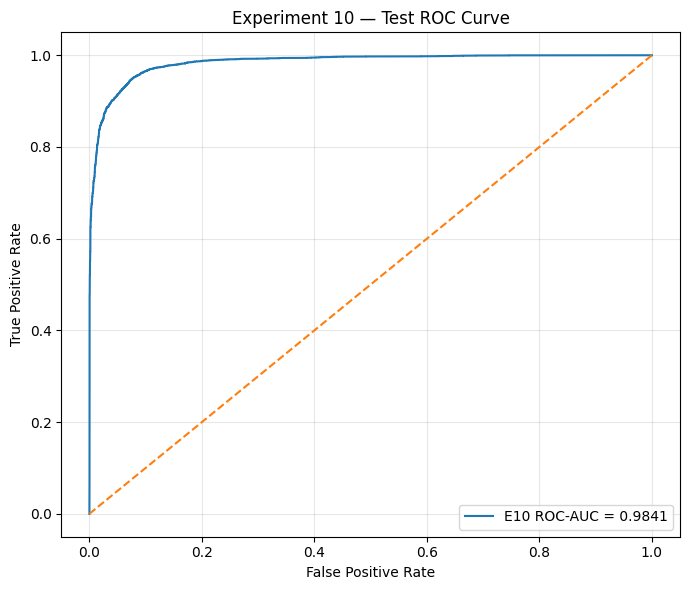

ROC curve saved:
/content/drive/MyDrive/DeepFake_Detection/DeepFake_Detection/experiments/cnn_128_final_regularized/graphs/test_roc_curve.png


In [18]:
# ============================================================
# CELL 13 â€” SAVE TEST ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    test_true,
    test_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"E10 ROC-AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Experiment 10 â€” Test ROC Curve")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

ROC_PATH = os.path.join(
    GRAPHS_DIR,
    "test_roc_curve.png"
)

plt.savefig(
    ROC_PATH,
    dpi=300
)

plt.show()

print("ROC curve saved:")
print(ROC_PATH)